In [1]:
%pip install pandas matplotlib seaborn plotly statsmodels

Note: you may need to restart the kernel to use updated packages.


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import statsmodels.formula.api as smf

In [3]:
# Data import & cleaning
r_and_d_expenditure = pd.read_csv('data/API_GB.XPD.RSDV.GD.ZS_DS2_en_csv_v2_232.csv', skiprows=4)
researchers_per_million = pd.read_csv('data/API_SP.POP.SCIE.RD.P6_DS2_en_csv_v2_37695.csv', skiprows=4)
PM_Exposure = pd.read_csv('data/API_SP.POP.SCIE.RD.P6_DS2_en_csv_v2_37695.csv', skiprows=4)
GDP_data = pd.read_csv('data/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_33610.csv', skiprows=4)

In [4]:
r_and_d_expenditure

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Research and development expenditure (% of GDP),GB.XPD.RSDV.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Research and development expenditure (% of GDP),GB.XPD.RSDV.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Research and development expenditure (% of GDP),GB.XPD.RSDV.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Research and development expenditure (% of GDP),GB.XPD.RSDV.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.277537,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Research and development expenditure (% of GDP),GB.XPD.RSDV.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,Kosovo,XKX,Research and development expenditure (% of GDP),GB.XPD.RSDV.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
261,"Yemen, Rep.",YEM,Research and development expenditure (% of GDP),GB.XPD.RSDV.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,South Africa,ZAF,Research and development expenditure (% of GDP),GB.XPD.RSDV.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,0.76257,0.68586,0.613040,0.60296,0.6139,0.61479,NaN,NaN,NaN,NaN
263,Zambia,ZMB,Research and development expenditure (% of GDP),GB.XPD.RSDV.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
researchers_per_million

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,Kosovo,XKX,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
261,"Yemen, Rep.",YEM,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,South Africa,ZAF,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,516.53674,500.79079,479.86558,459.98774,454.79773,444.16298,NaN,NaN,NaN,NaN
263,Zambia,ZMB,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
PM_Exposure

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,Kosovo,XKX,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
261,"Yemen, Rep.",YEM,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,South Africa,ZAF,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,516.53674,500.79079,479.86558,459.98774,454.79773,444.16298,NaN,NaN,NaN,NaN
263,Zambia,ZMB,Researchers in R&D (per million people),SP.POP.SCIE.RD.P6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
GDP_data

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30654.485124,22664.370995,26827.344787,31000.571380,34897.618393,38590.565029,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089515,186.909365,197.367876,225.400456,208.963066,226.836513,...,1529.923080,1553.617944,1508.031525,1351.503167,1560.894626,1675.902524,1571.132704,1628.227289,1722.385620,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,416.871146,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.551510,155.587905,...,1577.203497,1723.114463,2219.412555,2034.437940,2116.938294,2143.072094,1846.246811,1416.228412,1600.058374,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2832.149980,2891.830324,2507.868072,1749.179484,2266.968349,3598.536691,2885.513491,2720.819007,3129.476623,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,Kosovo,XKX,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,4009.320221,4384.187964,4415.699274,4320.583825,5269.699462,5298.147387,6220.332139,7026.698813,7899.418411,NaN
261,"Yemen, Rep.",YEM,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,811.165970,633.887202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
262,South Africa,ZAF,GDP per capita (current US$),NY.GDP.PCAP.CD,532.147504,545.657512,563.423009,604.536855,645.873376,684.621228,...,6618.335083,6914.178032,6533.711210,5580.603831,6828.756246,6534.248678,6034.272090,6267.186814,6597.714509,NaN
263,Zambia,ZMB,GDP per capita (current US$),NY.GDP.PCAP.CD,221.559849,209.693206,202.281031,203.219451,229.979246,287.425476,...,1483.465773,1463.899979,1258.986198,951.644317,1127.160779,1447.123101,1330.727806,1187.109434,1317.877716,NaN


In [8]:
r_and_d_expenditure = r_and_d_expenditure.drop(columns=[c for c in r_and_d_expenditure.columns if "Unnamed" in c])
years = [c for c in r_and_d_expenditure.columns if c[:4].isdigit()]
r_and_d_expenditure = r_and_d_expenditure.melt(id_vars=["Country Name", "Country Code"],          # = Unpivot Other Columns
                                   value_vars=years, var_name="Year", value_name="R&D Expenditure")
r_and_d_expenditure = r_and_d_expenditure.dropna(subset=["R&D Expenditure"])
r_and_d_expenditure["Year"] = r_and_d_expenditure["Year"].astype(int)
r_and_d_expenditure

,Country Name,Country Code,Year,R&D Expenditure
9549,Argentina,ARG,1996,0.41749
9553,Australia,AUS,1996,1.66218
9554,Austria,AUT,1996,1.58947
9555,Azerbaijan,AZE,1996,0.23533
9557,Belgium,BEL,1996,1.74299
...,...,...,...,...
17164,Saudi Arabia,SAU,2024,0.63522
17173,Serbia,SRB,2024,0.93978
17191,Togo,TGO,2024,0.22229
17207,Ukraine,UKR,2024,0.36988


In [9]:
researchers_per_million = researchers_per_million.drop(columns=[c for c in researchers_per_million.columns if "Unnamed" in c])
years = [c for c in researchers_per_million.columns if c[:4].isdigit()]
researchers_per_million = researchers_per_million.melt(id_vars=["Country Name", "Country Code"],          # = Unpivot Other Columns
                                   value_vars=years, var_name="Year", value_name="Researchers per Million")
researchers_per_million = researchers_per_million.dropna(subset=["Researchers per Million"])
researchers_per_million["Year"] = researchers_per_million["Year"].astype(int)
researchers_per_million

,Country Name,Country Code,Year,Researchers per Million
9553,Australia,AUS,1996,3353.705300
9557,Belgium,BEL,1996,2477.439060
9561,Bulgaria,BGR,1996,1771.854220
9575,Canada,CAN,1996,3055.672470
9576,Central Europe and the Baltics,CEB,1996,1410.613645
...,...,...,...,...
17173,Serbia,SRB,2024,2687.547080
17191,Togo,TGO,2024,57.794020
17202,Tunisia,TUN,2024,1667.611640
17209,Uruguay,URY,2024,937.570390


In [10]:
PM_Exposure = PM_Exposure.drop(columns=[c for c in PM_Exposure.columns if "Unnamed" in c])
years = [c for c in PM_Exposure.columns if c[:4].isdigit()]
PM_Exposure = PM_Exposure.melt(id_vars=["Country Name", "Country Code"],          # = Unpivot Other Columns
                               value_vars=years, var_name="Year", value_name="PM Exposure")
PM_Exposure = PM_Exposure.dropna(subset=["PM Exposure"])
PM_Exposure["Year"] = PM_Exposure["Year"].astype(int)
PM_Exposure

,Country Name,Country Code,Year,PM Exposure
9553,Australia,AUS,1996,3353.705300
9557,Belgium,BEL,1996,2477.439060
9561,Bulgaria,BGR,1996,1771.854220
9575,Canada,CAN,1996,3055.672470
9576,Central Europe and the Baltics,CEB,1996,1410.613645
...,...,...,...,...
17173,Serbia,SRB,2024,2687.547080
17191,Togo,TGO,2024,57.794020
17202,Tunisia,TUN,2024,1667.611640
17209,Uruguay,URY,2024,937.570390


In [11]:
GDP_data = GDP_data.drop(columns=[c for c in GDP_data.columns if "Unnamed" in c])
years = [c for c in GDP_data.columns if c[:4].isdigit()]
GDP_data = GDP_data.melt(id_vars=["Country Name", "Country Code"],          # = Unpivot Other Columns
                               value_vars=years, var_name="Year", value_name="GDP per Capita")
GDP_data = GDP_data.dropna(subset=["GDP per Capita"])
GDP_data["Year"] = GDP_data["Year"].astype(int)
GDP_data

,Country Name,Country Code,Year,GDP per Capita
1,Africa Eastern and Southern,AFE,1960,186.089515
3,Africa Western and Central,AFW,1960,121.936832
9,Argentina,ARG,1960,778.251707
13,Australia,AUS,1960,1813.431099
14,Austria,AUT,1960,939.914815
...,...,...,...,...
17484,Samoa,WSM,2025,5872.783333
17485,Kosovo,XKX,2025,7899.418411
17487,South Africa,ZAF,2025,6597.714509
17488,Zambia,ZMB,2025,1317.877716


In [15]:
df = r_and_d_expenditure.merge(PM_Exposure, on=["Country Name", "Country Code", "Year"], how="inner")
df = df.merge(researchers_per_million, on=["Country Name", "Country Code", "Year"], how="inner")
df = df.merge(GDP_data, on=["Country Name", "Country Code", "Year"], how="inner")
df, print(df.columns.tolist())

['Country Name', 'Country Code', 'Year', 'R&D Expenditure', 'PM Exposure', 'Researchers per Million', 'GDP per Capita']


(                        Country Name Country Code  Year  R&D Expenditure  \
 0                          Australia          AUS  1996         1.662180   
 1                            Belgium          BEL  1996         1.742990   
 2                           Bulgaria          BGR  1996         0.418260   
 3                             Canada          CAN  1996         1.606820   
 4     Central Europe and the Baltics          CEB  1996         0.718818   
 ...                              ...          ...   ...              ...   
 2372              Russian Federation          RUS  2024         0.937060   
 2373                    Saudi Arabia          SAU  2024         0.635220   
 2374                          Serbia          SRB  2024         0.939780   
 2375                            Togo          TGO  2024         0.222290   
 2376                      Uzbekistan          UZB  2024         0.104160   
 
       PM Exposure  Researchers per Million  GDP per Capita  
 0     3353.

In [ ]:
# Data visualization
px.choropleth(df, locations="Country Code", color="PM Exposure", locationmode="ISO-3").show()

<Axes: xlabel='R&D Expenditure', ylabel='PM Exposure'>

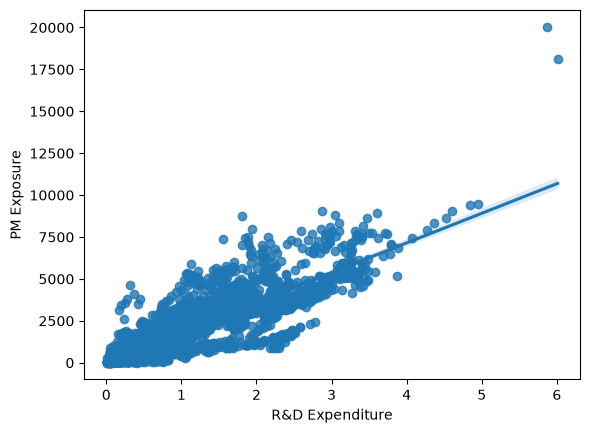

In [16]:
sns.regplot(x="R&D Expenditure", y="PM Exposure", data=df)

In [ ]:
d = df[df.Year == 2023].copy()
d["logGDP"] = np.log10(d["GDPperCapita"])

m1 = smf.ols("PM25 ~ RnDPctGDP", data=d).fit()              # naive
m2 = smf.ols("PM25 ~ RnDPctGDP + logGDP", data=d).fit()     # controlling for income
print(m2.summary())
m3 = smf.ols("PM25 ~ logGDP + I(logGDP**2)", data=d).fit()
smf.ols("PM25 ~ RnDPctGDP + logGDP", data=df)